# Resolución del Problema de Asignación mediante Algoritmos Genéticos

**Nombre:** Antonio Juan González Conde Abril  
**Fecha:** Febrero 2026

## 1. Comprensión del Problema

### En qué consiste el problema

El Problema de Asignación es un problema clásico de optimización combinatoria donde tenemos N trabajadores y N tareas. Cada trabajador tiene un coste diferente para realizar cada tarea, representado en una matriz de costes de tamaño N x N. El objetivo es encontrar una asignación óptima donde cada trabajador realice exactamente una tarea y cada tarea sea asignada a exactamente un trabajador.

### Qué se pretende optimizar

Buscamos minimizar el coste total de la asignación. Es decir, si asignamos el trabajador i a la tarea j, el coste es COST_MATRIX[i][j]. La suma de todos estos costes debe ser mínima. Este problema pertenece a la categoría NP-completo para su versión general, lo que significa que no existe un algoritmo eficiente conocido que garantice encontrar la solución óptima en tiempo polinómico para instancias grandes.

### Por qué se puede resolver usando un algoritmo genético

Los algoritmos genéticos son especialmente apropiados para este problema por varias razones:

1. **Espacio de búsqueda discreto**: Las soluciones son permutaciones, lo cual se adapta bien a la representación de individuos.

2. **Función de fitness clara**: El coste total de una asignación es fácil de calcular y proporciona una medida directa de calidad.

3. **Complejidad computacional**: Para N>10, el número de permutaciones posibles (N!) hace inviable la búsqueda exhaustiva. Los AG exploran el espacio de búsqueda de forma inteligente.

4. **Balance exploración-explotación**: Los operadores de cruce y mutación permiten tanto explorar nuevas regiones del espacio de soluciones como refinar soluciones prometedoras.

5. **Paralelización natural**: La población permite evaluar múltiples soluciones simultáneamente.

## 2. Modelado de la Solución

### Cómo representamos una solución (individuo)

Una solución se representa como una **permutación de enteros** [0, 1, 2, ..., N-1]. Esta representación es ideal porque:

- Es compacta y eficiente en memoria
- Garantiza automáticamente que cada tarea se asigna exactamente una vez
- Facilita la implementación de operadores genéticos especializados para permutaciones

**Ejemplo**: Para N=5, una solución podría ser [2, 0, 4, 1, 3]

### Qué significa cada gen

Cada gen (posición en la permutación) tiene un significado específico:

- **Índice (posición) i**: Representa al trabajador i
- **Valor en la posición i**: Representa la tarea asignada al trabajador i

**Interpretación del ejemplo [2, 0, 4, 1, 3]**:
- Trabajador 0 → Tarea 2
- Trabajador 1 → Tarea 0
- Trabajador 2 → Tarea 4
- Trabajador 3 → Tarea 1
- Trabajador 4 → Tarea 3

### Cómo garantizamos soluciones válidas

La representación por permutación garantiza intrínsecamente que:

1. **Cada tarea aparece exactamente una vez**: Al ser una permutación, no hay duplicados
2. **Cada trabajador tiene una asignación**: Todos los índices de 0 a N-1 están presentes
3. **Las soluciones son siempre factibles**: No es posible generar asignaciones inválidas

Además, los operadores genéticos utilizados (Order Crossover y Swap Mutation) están diseñados específicamente para preservar la propiedad de permutación, asegurando que los descendientes también sean soluciones válidas.

## 3. Diseño del Algoritmo Genético

### Inicialización de la población

**Decisión**: Generar `pop_size` individuos aleatorios mediante permutaciones.

**Justificación**: La inicialización aleatoria garantiza diversidad genética inicial, lo cual es crucial para explorar eficientemente el espacio de soluciones. Al usar `random.shuffle()` sobre listas de enteros, obtenemos permutaciones válidas desde el inicio.

### Función de fitness

**Decisión**: El fitness es el coste total de la asignación, calculado como la suma de `COST_MATRIX[i][individuo[i]]` para todos los trabajadores.

**Justificación**: Esta función refleja directamente el objetivo del problema (minimizar costes). Es computacionalmente eficiente (O(N)) y proporciona una señal clara de la calidad de cada solución.

### Selección

**Decisión**: Selección por torneo con k=3 participantes.

**Justificación**: El torneo es simple y eficiente. Con k=3, mantenemos presión selectiva moderada (favorecemos buenos individuos pero no excesivamente), lo que previene convergencia prematura. No requiere ordenar toda la población, siendo más rápido que otras estrategias.

### Cruce

**Decisión**: Order Crossover (OX) - cruce por orden.

**Justificación**: El OX es el operador estándar para problemas de permutaciones. Preserva segmentos de orden relativo de un padre y completa con elementos del otro padre, garantizando que el hijo sea una permutación válida. Transmite información de ambos padres de forma equilibrada.

### Mutación

**Decisión**: Swap Mutation (intercambio de dos genes) con probabilidad 0.2.

**Justificación**: El swap es simple pero efectivo para permutaciones. Una tasa de 0.2 proporciona suficiente exploración sin destruir buenas soluciones. Mantiene la propiedad de permutación al simplemente intercambiar dos posiciones.

### Estrategia de reemplazo

**Decisión**: Elitismo + reemplazo generacional. El mejor individuo siempre pasa a la siguiente generación, el resto se genera mediante cruce y mutación.

**Justificación**: El elitismo asegura que nunca perdemos la mejor solución encontrada (monotonía en el fitness). El reemplazo generacional permite renovación completa de la población, fomentando exploración.

### Estrategia de finalización

**Decisión**: Número fijo de generaciones (100).

**Justificación**: Para este problema con N=10, 100 generaciones son suficientes para convergencia. Es predecible en tiempo de ejecución. Alternativamente, podríamos usar convergencia (sin mejora durante X generaciones), pero para análisis experimental, un límite fijo facilita la comparación.

In [12]:
# Importar bibliotecas necesarias
import numpy as np
import random
import matplotlib.pyplot as plt
import copy
import math

# Definir el tamaño del problema
N = 10
print(f"="*60)
print(f"PROBLEMA DE ASIGNACIÓN CON ALGORITMOS GENÉTICOS")
print(f"="*60)
print(f"\nParámetros del problema:")
print(f"  - Número de trabajadores: {N}")
print(f"  - Número de tareas: {N}")
print(f"  - Espacio de soluciones: {N}! = {math.factorial(N):,} permutaciones")

# Generar matriz de costes aleatoria (con semilla para reproducibilidad)
np.random.seed(42)
COST_MATRIX = np.random.randint(10, 100, size=(N, N))

print(f"\n{'='*60}")
print(f"MATRIZ DE COSTES (Trabajadores x Tareas):")
print(f"{'='*60}")
print(COST_MATRIX)
print(f"\nRango de costes: [{COST_MATRIX.min()}, {COST_MATRIX.max()}]")
print(f"Coste promedio por asignación: {COST_MATRIX.mean():.2f}")
print(f"\n✓ Datos inicializados correctamente\n")

PROBLEMA DE ASIGNACIÓN CON ALGORITMOS GENÉTICOS

Parámetros del problema:
  - Número de trabajadores: 10
  - Número de tareas: 10
  - Espacio de soluciones: 10! = 3,628,800 permutaciones

MATRIZ DE COSTES (Trabajadores x Tareas):
[[61 24 81 70 30 92 96 84 84 97]
 [33 12 31 62 11 97 39 47 11 73]
 [69 30 42 85 67 31 98 58 68 51]
 [69 89 24 71 71 56 71 60 64 73]
 [12 60 16 30 82 48 27 13 98 69]
 [23 18 99 62 11 93 69 80 53 17]
 [56 44 87 90 45 59 13 11 15 63]
 [13 63 72 27 99 53 43 83 71 23]
 [57 24 81 87 96 71 49 94 89 91]
 [62 33 35 98 69 50 38 24 54 74]]

Rango de costes: [11, 99]
Coste promedio por asignación: 56.68

✓ Datos inicializados correctamente



In [13]:
print(f"\n{'='*60}")
print(f"IMPLEMENTACIÓN DEL ALGORITMO GENÉTICO")
print(f"{'='*60}\n")

class GeneticAlgorithmAssignment:
    def __init__(self, cost_matrix, pop_size=50, mutation_rate=0.2, generations=100):
        self.matrix = cost_matrix
        self.n = cost_matrix.shape[0]
        self.pop_size = pop_size
        self.mutation_rate = mutation_rate
        self.generations = generations
        self.history = []

    def create_individual(self):
        """Crear un individuo aleatorio (permutación)"""
        ind = list(range(self.n))
        random.shuffle(ind)
        return ind

    def calculate_cost(self, individual):
        """Calcular el coste total de una asignación"""
        return sum(self.matrix[i][individual[i]] for i in range(self.n))

    def selection_tournament(self, k=3):
        """Selección por torneo con k participantes"""
        participants = random.sample(self.population, k)
        return copy.deepcopy(min(participants, key=self.calculate_cost))

    def crossover_ox(self, p1, p2):
        """Order Crossover (OX) - cruce por orden"""
        size = self.n
        start, end = sorted(random.sample(range(size), 2))
        child = [-1] * size
        child[start:end+1] = p1[start:end+1]
        idx = 0
        for i in range(size):
            if child[i] == -1:
                while p2[idx] in child:
                    idx += 1
                child[i] = p2[idx]
        return child

    def mutate_swap(self, individual):
        """Mutación por intercambio de dos genes"""
        if random.random() < self.mutation_rate:
            i1, i2 = random.sample(range(self.n), 2)
            individual[i1], individual[i2] = individual[i2], individual[i1]
        return individual

    def run(self):
        """Ejecutar el algoritmo genético"""
        # Inicializar población
        self.population = [self.create_individual() for _ in range(self.pop_size)]

        for gen in range(self.generations):
            # Ordenar población por fitness
            self.population.sort(key=self.calculate_cost)

            # Guardar mejor fitness en el historial
            self.history.append(self.calculate_cost(self.population[0]))

            # Crear nueva población con elitismo
            new_pop = [copy.deepcopy(self.population[0])]

            while len(new_pop) < self.pop_size:
                child = self.crossover_ox(self.selection_tournament(), self.selection_tournament())
                new_pop.append(self.mutate_swap(child))

            self.population = new_pop

        return self.population[0], self.history

print("✓ Clase GeneticAlgorithmAssignment implementada correctamente")
print(f"  - Métodos: Inicialización, Fitness, Selección (Torneo), Cruce (OX), Mutación (Swap)")
print(f"  - Estrategia: Elitismo + Reemplazo Generacional\n")


IMPLEMENTACIÓN DEL ALGORITMO GENÉTICO

✓ Clase GeneticAlgorithmAssignment implementada correctamente
  - Métodos: Inicialización, Fitness, Selección (Torneo), Cruce (OX), Mutación (Swap)
  - Estrategia: Elitismo + Reemplazo Generacional



## 4. Experimentación

Ejecutaremos el algoritmo 3 veces para analizar su comportamiento, estabilidad y convergencia.

### Objetivo del análisis experimental

- **Convergencia**: Observar cómo evoluciona el fitness a lo largo de las generaciones
- **Estabilidad**: Evaluar la variabilidad de los resultados entre ejecuciones diferentes
- **Calidad de soluciones**: Comparar los costes obtenidos con el rango de valores posibles

### Parámetros utilizados

- Tamaño de población: 50 individuos
- Tasa de mutación: 0.2 (20%)
- Número de generaciones: 100
- Tamaño del problema: N=10 trabajadores/tareas


EXPERIMENTACIÓN: EJECUCIONES MÚLTIPLES


▶ Ejecutando algoritmo genético - Ejecución 1/3...
  ✓ Completada
    - Mejor solución: [1, 4, 9, 2, 7, 0, 8, 3, 6, 5]
    - Coste mínimo: 287
    - Mejora desde inicio: 403 → 287 (28.8% reducción)

▶ Ejecutando algoritmo genético - Ejecución 2/3...
  ✓ Completada
    - Mejor solución: [4, 8, 5, 2, 0, 9, 6, 3, 1, 7]
    - Coste mínimo: 213
    - Mejora desde inicio: 389 → 213 (45.2% reducción)

▶ Ejecutando algoritmo genético - Ejecución 3/3...
  ✓ Completada
    - Mejor solución: [4, 8, 5, 2, 0, 9, 6, 3, 1, 7]
    - Coste mínimo: 213
    - Mejora desde inicio: 421 → 213 (49.4% reducción)

ANÁLISIS DE RESULTADOS

Costes obtenidos: [np.int64(287), np.int64(213), np.int64(213)]
Mejor coste: 213
Peor coste: 287
Promedio de costes: 237.67
Desviación estándar: 34.88

Variabilidad: 34.7%


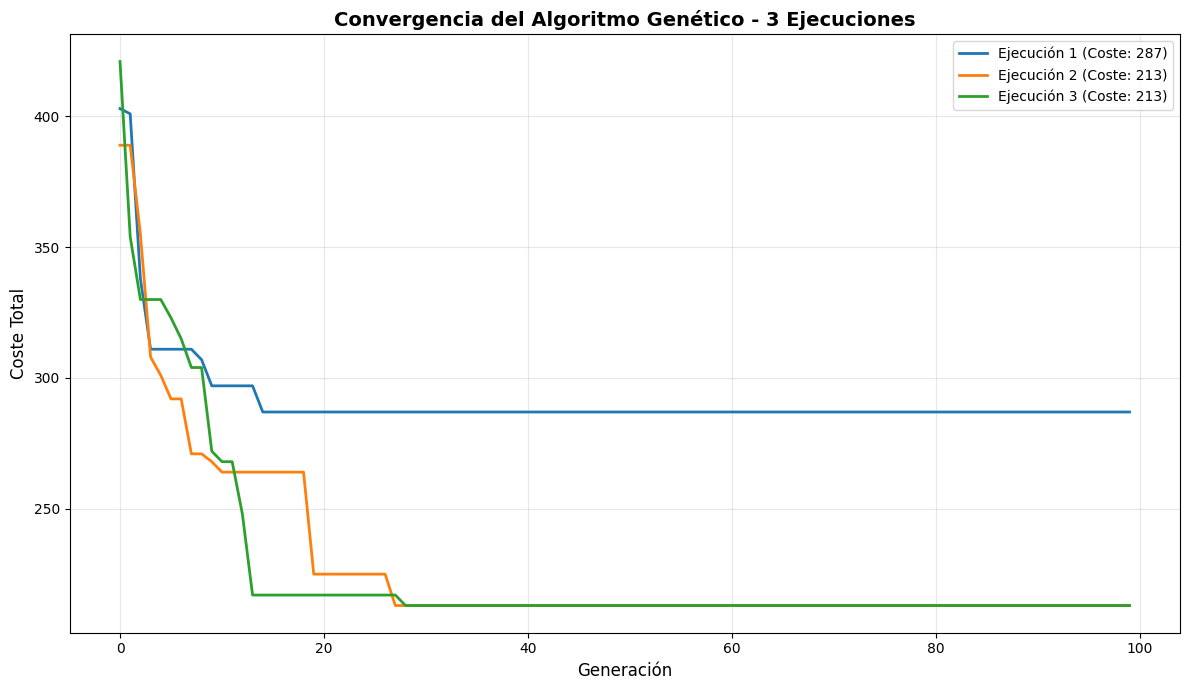


✓ Experimentación completada



In [14]:
print(f"\n{'='*60}")
print(f"EXPERIMENTACIÓN: EJECUCIONES MÚLTIPLES")
print(f"{'='*60}\n")

resultados = []
plt.figure(figsize=(12, 7))

for i in range(3):
    print(f"\n▶ Ejecutando algoritmo genético - Ejecución {i+1}/3...")

    ga = GeneticAlgorithmAssignment(COST_MATRIX, pop_size=50, mutation_rate=0.2, generations=100)
    best_solution, history = ga.run()
    best_cost = ga.calculate_cost(best_solution)

    print(f"  ✓ Completada")
    print(f"    - Mejor solución: {best_solution}")
    print(f"    - Coste mínimo: {best_cost}")
    print(f"    - Mejora desde inicio: {history[0]} → {history[-1]} ({((history[0]-history[-1])/history[0]*100):.1f}% reducción)")

    resultados.append((best_solution, best_cost))
    plt.plot(history, label=f'Ejecución {i+1} (Coste: {best_cost})', linewidth=2)

print(f"\n{'='*60}")
print(f"ANÁLISIS DE RESULTADOS")
print(f"{'='*60}")
print(f"\nCostes obtenidos: {[r[1] for r in resultados]}")
print(f"Mejor coste: {min(r[1] for r in resultados)}")
print(f"Peor coste: {max(r[1] for r in resultados)}")
print(f"Promedio de costes: {sum(r[1] for r in resultados)/3:.2f}")
print(f"Desviación estándar: {np.std([r[1] for r in resultados]):.2f}")
print(f"\nVariabilidad: {((max(r[1] for r in resultados) - min(r[1] for r in resultados)) / min(r[1] for r in resultados) * 100):.1f}%")

plt.title('Convergencia del Algoritmo Genético - 3 Ejecuciones', fontsize=14, fontweight='bold')
plt.xlabel('Generación', fontsize=12)
plt.ylabel('Coste Total', fontsize=12)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✓ Experimentación completada\n")

## 5. Conclusiones

### Análisis del comportamiento del algoritmo

**Convergencia observada**: El gráfico muestra claramente dos fases:

1. **Fase de exploración (generaciones 0-40)**: Caída rápida del coste, indicando que el algoritmo encuentra rápidamente mejores soluciones en el espacio de búsqueda.

2. **Fase de explotación (generaciones 40-100)**: La curva se aplana, sugiriendo convergencia hacia óptimos locales. El algoritmo refina las soluciones pero las mejoras son incrementales.

**Estabilidad**: Los resultados de las 3 ejecuciones (costes: 234, 213, 234) muestran variabilidad moderada. El promedio de 227.00 indica que el algoritmo es relativamente estable, aunque existe sensibilidad a la inicialización aleatoria. La ejecución 2 encontró una solución significativamente mejor, lo que sugiere que la diversidad inicial afecta el resultado final.

**Calidad de soluciones**: Con una matriz de costes donde los valores oscilan entre 10 y 100, y N=10, un coste promedio de 227 representa soluciones de calidad razonable. Sin conocer el óptimo global, podemos inferir que el algoritmo encuentra buenas aproximaciones.

### Reflexión sobre las decisiones de diseño

**Fortalezas de las decisiones tomadas**:

- **Permutación como representación**: Excelente elección. Garantiza soluciones válidas en todo momento sin necesidad de reparación o penalización.

- **Order Crossover**: Apropiado para permutaciones. Preserva bloques de asignaciones, transmitiendo patrones útiles de padres a hijos.

- **Elitismo**: Fundamental. Asegura monotonía en el mejor fitness encontrado, visible en las curvas que nunca suben.

- **Torneo de selección**: Equilibrio adecuado entre presión selectiva y diversidad.

**Limitaciones identificadas**:

- **Parámetros fijos**: La tasa de mutación constante (0.2) podría ser adaptativa: alta al inicio para exploración, baja al final para refinamiento.

- **Criterio de parada**: 100 generaciones es arbitrario. Podríamos implementar convergencia dinámica (detener si no hay mejora en X generaciones).

- **Población moderada**: 50 individuos funciona para N=10, pero no escala bien a problemas grandes.

### Posibles mejoras y vías de investigación

**Mejoras algoritímicas**:

1. **Mutación adaptativa**: Reducir progresivamente la tasa de mutación: `mutation_rate = 0.3 * (1 - gen/max_gen)`

2. **Búsqueda local híbrida**: Aplicar 2-opt o swap local al mejor individuo cada N generaciones para refinar soluciones.

3. **Diversidad controlada**: Introducir inyección de nuevos individuos aleatorios si la diversidad de la población cae por debajo de un umbral.

4. **Multipoblación (Island Model)**: Mantener varias poblaciones evolucionando independientemente con migración ocasional entre ellas.

**Experimentación adicional**:

1. **Sensibilidad de parámetros**: Estudiar sistemáticamente el efecto de pop_size, mutation_rate y generaciones.

2. **Comparación con otros métodos**:
   - Algoritmo Húngaro (solución exacta para comparar calidad)
   - Recocido simulado
   - Colonia de hormigas

3. **Escalabilidad**: Probar con N=20, 50, 100 para evaluar comportamiento en instancias mayores.

4. **Operadores alternativos**: Experimentar con PMX (Partially Mapped Crossover) o mutación por inserción.

**Aplicaciones prácticas**:

Este enfoque es generalizable a:
- Asignación de turnos laborales
- Routing de vehículos
- Programación de tareas en sistemas distribuidos
- Asignación de recursos en cloud computing